#### Import

In [131]:
import pathlib
from pathlib import Path

#import cartopy.crs as ccrs
#import filefisher

import importlib
import matplotlib.pyplot as plt
import calendar
import numpy as np
import xarray as xr
import pandas as pd
from xarray import DataTree
import math


import warnings
import Play
import mesmer
import model 
import sklearn

import xskillscore as xs

from scipy.stats import (
    norm,
    gamma,
    beta,
    expon,
    weibull_min,
    lognorm,
    uniform,
    t,
    pareto
)

#from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression


In [66]:
tas = Play.shape_data.show_data_set("tas")
pr = Play.shape_data.show_data_set("pr")
tas = Play.shape_data.prune_group_ds_timespan(tas, Month_idx=1)
pr = Play.shape_data.prune_group_ds_timespan(pr, Month_idx=1)
tas = tas.mean("lat").mean("lon")
pr = pr.mean("lat").mean("lon")
mes_predictors = xr.merge([tas,pr]).drop_vars("file_qf")

In [67]:
target = Play.shape_data.show_data_set("mrsol").isel(depth = 0)

target = Play.shape_data.prune_group_ds_timespan(target, Month_idx=1)

target = target.drop_vars("depth_bnds")


mes_target = target.mean("lat").mean("lon")


In [76]:
tuple(mes_predictors.values())
mes_predictors_concat = xr.concat(
            tuple(mes_predictors.values()),
            dim="predictor",
            join="exact",
            coords="minimal",
        )
mes_predictors_concat = mes_predictors_concat.assign_coords(
            {"predictor": list(mes_predictors.keys())}
        )

In [77]:
mes_predictors_concat

<xarray.DataArray 'tas' (predictor: 2, time: 50)> Size: 800B
array([[2.75559822e+02, 2.75098800e+02, 2.75987479e+02, 2.75852070e+02,
        2.76379805e+02, 2.75612710e+02, 2.75373530e+02, 2.75301837e+02,
        2.75919089e+02, 2.75834489e+02, 2.75924519e+02, 2.76003144e+02,
        2.75908992e+02, 2.75794177e+02, 2.76116366e+02, 2.76055504e+02,
        2.75694799e+02, 2.76175613e+02, 2.75975679e+02, 2.75770840e+02,
        2.75629988e+02, 2.75906419e+02, 2.75981290e+02, 2.75866778e+02,
        2.76217896e+02, 2.75476368e+02, 2.75209707e+02, 2.75482444e+02,
        2.75748093e+02, 2.76159796e+02, 2.75496579e+02, 2.75378011e+02,
        2.75585619e+02, 2.75565400e+02, 2.75828733e+02, 2.75390638e+02,
        2.75693155e+02, 2.75478344e+02, 2.75722232e+02, 2.76067104e+02,
        2.75783628e+02, 2.75212278e+02, 2.75650521e+02, 2.75223495e+02,
        2.75449658e+02, 2.75802261e+02, 2.75711662e+02, 2.75841684e+02,
        2.75573749e+02, 2.75532860e+02],
       [2.61633031e-05, 2.59467863e-05, 2.62518105e-05, 2.64117456e-05,
        2.60959250e-05, 2.64735073e-05, 2.60788016e-05, 2.57398269e-05,
        2.56681819e-05, 2.68642713e-05, 2.64967004e-05, 2.63859500e-05,
        2.58146949e-05, 2.62270850e-05, 2.62550925e-05, 2.59741348e-05,
        2.60750833e-05, 2.60931356e-05, 2.62614701e-05, 2.57694984e-05,
        2.61287908e-05, 2.58674416e-05, 2.61164339e-05, 2.61767540e-05,
        2.65336494e-05, 2.58767434e-05, 2.60526507e-05, 2.56466237e-05,
        2.56136851e-05, 2.60785141e-05, 2.59252704e-05, 2.58575519e-05,
        2.56638574e-05, 2.56513743e-05, 2.58213381e-05, 2.52863749e-05,
        2.57595233e-05, 2.59821602e-05, 2.54714036e-05, 2.62555884e-05,
        2.57195625e-05, 2.59811247e-05, 2.53572945e-05, 2.58269010e-05,
        2.57955851e-05, 2.63646238e-05, 2.61726304e-05, 2.62298122e-05,
        2.60647074e-05, 2.62896718e-05]])
Coordinates:
  * predictor  (predictor) <U3 24B 'tas' 'pr'
  * time       (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
    height     float64 8B 2.0
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    comment:        near-surface (usually, 2 meter) air temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [68]:
mesmer_LinReg = mesmer.stats.LinearRegression()
mesmer_LinReg.fit(predictors=mes_predictors,target=mes_target.mrsol,dim="time")

In [120]:
tas = Play.shape_data.show_data_set("tas")
pr = Play.shape_data.show_data_set("pr")
tas = Play.shape_data.prune_group_ds_timespan(tas, Month_idx=1)
pr = Play.shape_data.prune_group_ds_timespan(pr, Month_idx=1)
tas = tas.isel(
    lat=slice(27, 29),
    lon=slice(5, 8)
)

tas = tas.stack(gridcell=("lat","lon"))

pr = pr.isel(
    lat=slice(27, 29),
    lon=slice(5, 8)
)

pr = pr.stack(gridcell=("lat","lon"))
predictors = xr.merge([tas,pr]).drop_vars("file_qf")

In [121]:
predictors

<xarray.Dataset> Size: 5kB
Dimensions:   (time: 50, gridcell: 6)
Coordinates:
  * time      (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
  * gridcell  (gridcell) object 48B MultiIndex
  * lat       (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon       (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
    height    float64 8B 2.0
Data variables:
    tas       (time, gridcell) float64 2kB 277.7 274.1 273.2 ... 279.2 277.6
    pr        (time, gridcell) float64 2kB 1.046e-05 9.659e-06 ... 7.813e-06
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:13:55 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/6b679cba-17b8-45eb-90dc-23d170c1998c
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  44b9ee9e68daceb1f50e9680dcfb7744f0e272d73c5e18...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [122]:
target = Play.shape_data.show_data_set("mrsol").isel(depth = 0)

target = Play.shape_data.prune_group_ds_timespan(target, Month_idx=1)

target = target.drop_vars("depth_bnds")


target = target.isel(
    lat=slice(27, 29),
    lon=slice(5, 8)
)

target = target.stack(gridcell=("lat","lon"))


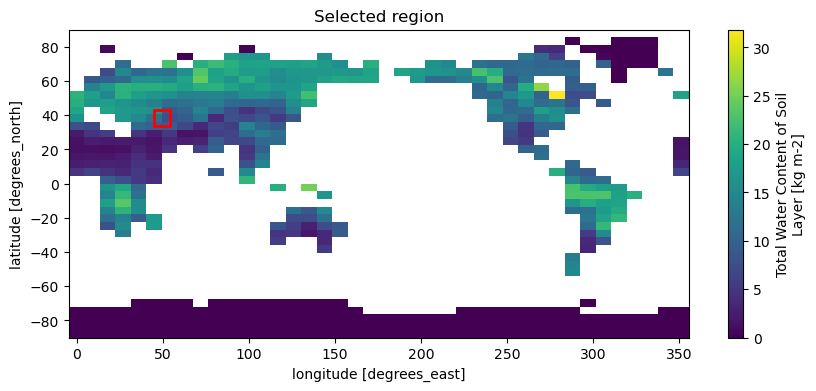

In [123]:
Play.plot_one_var.show_my_position(min_lat_idx=27,max_lat_idx=29, lon_idx=5, max_lon_idx=6)

In [124]:
target

<xarray.Dataset> Size: 3kB
Dimensions:   (time: 50, gridcell: 6)
Coordinates:
  * time      (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
  * gridcell  (gridcell) object 48B MultiIndex
  * lat       (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon       (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
    depth     float64 8B 0.03
Data variables:
    mrsol     (time, gridcell) float64 2kB 9.782 9.285 6.886 ... 10.67 9.393
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [125]:
tuple(predictors.values())

(<xarray.DataArray 'tas' (time: 50, gridcell: 6)> Size: 2kB
 array([[277.68300924, 274.05676509, 273.17991221, 267.24856022,
         274.7525469 , 270.33461709],
        [279.95749731, 278.04207207, 276.5484348 , 269.20622261,
         278.64049562, 277.78224681],
        [277.46536269, 276.61106245, 273.10937691, 268.06026428,
         277.37486375, 274.02525082],
        [275.78310061, 271.27177987, 269.95615662, 266.11363051,
         272.0321159 , 269.08305935],
        [281.7199114 , 280.09289638, 276.69129237, 273.38454137,
         282.21107009, 279.00595883],
        [279.71626692, 276.04303485, 273.00041024, 270.86217698,
         278.09568227, 274.83676498],
        [279.20711658, 277.42172976, 275.43113858, 270.26816746,
         279.01394639, 277.10475714],
        [277.89299751, 275.86739354, 272.52878192, 268.71299123,
         276.62872747, 274.71874184],
        [280.23892634, 277.28961947, 274.33104521, 271.31341923,
         279.20995837, 276.91097065],
        [277.

In [126]:
predictors_concat = xr.concat(
            tuple(predictors.values()),
            dim="predictor",
            join="exact",
            coords="minimal",
        )
predictors_concat = predictors_concat.assign_coords(
            {"predictor": list(predictors.keys())}
        )
predictors_concat.dims

('predictor', 'time', 'gridcell')

In [ ]:
importlib.reload(model.stats._linear_regression)
from model.stats._linear_regression import LinearRegression

model_vec_LinReg = model.stats._linear_regression.LinearRegression()
model_vec_LinReg.fit(predictors=predictors,target=target.mrsol,location_dim="gridcell",regr_dim="time")

In [155]:
model_vec_LinReg.params

<xarray.Dataset> Size: 289B
Dimensions:        (gridcell: 6)
Coordinates:
  * gridcell       (gridcell) object 48B MultiIndex
  * lat            (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon            (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
Data variables:
    intercept      (gridcell) float64 48B 64.56 62.48 87.15 18.24 73.5 50.92
    tas            (gridcell) float64 48B -0.207 -0.2069 ... -0.2395 -0.1582
    pr             (gridcell) float64 48B 1.819e+05 3.815e+05 ... 2.045e+05
    fit_intercept  bool 1B True

In [158]:
regr_mat = Play.LinReg_building.global_vars_to_one_dim(min_lat_idx=27, max_lat_idx= 29, min_lon_idx=5, max_lon_idx=8, Month_idx=1, end="1900-01-01")

In [164]:
regr_mat[1][2].intercept_

np.float64(50.91856695816045)

In [97]:
print(regr.coef_)
regr.intercept_

[-2.07036945e-01  1.81877603e+05]


np.float64(64.55990341763358)

In [11]:
model_linReg = model.stats.LinearRegression()

In [12]:
model_linReg.fit(predictors=predictors,target=target.mrsol,dim="time")

In [13]:
mesmer_LinReg.params

<xarray.Dataset> Size: 289B
Dimensions:        (gridcell: 6)
Coordinates:
  * gridcell       (gridcell) object 48B MultiIndex
  * lat            (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon            (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
Data variables:
    intercept      (gridcell) float64 48B -418.9 -237.0 -359.2 ... -454.0 -213.9
    tas            (gridcell) float64 48B 1.605 0.9231 1.471 0.1699 1.62 0.821
    pr             (gridcell) float64 48B -5.853e+05 -3.889e+05 ... -1.114e+05
    fit_intercept  bool 1B True

In [14]:
mesmer_LinReg.params

<xarray.Dataset> Size: 289B
Dimensions:        (gridcell: 6)
Coordinates:
  * gridcell       (gridcell) object 48B MultiIndex
  * lat            (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon            (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
Data variables:
    intercept      (gridcell) float64 48B -418.9 -237.0 -359.2 ... -454.0 -213.9
    tas            (gridcell) float64 48B 1.605 0.9231 1.471 0.1699 1.62 0.821
    pr             (gridcell) float64 48B -5.853e+05 -3.889e+05 ... -1.114e+05
    fit_intercept  bool 1B True

In [165]:
tas = Play.shape_data.show_data_set("tas", run_idx=2)
pr = Play.shape_data.show_data_set("pr", run_idx=2)
tas = Play.shape_data.prune_group_ds_timespan(tas, Month_idx=1)
pr = Play.shape_data.prune_group_ds_timespan(pr, Month_idx=1)
tas = tas.isel(
    lat=slice(27, 29),
    lon=slice(5, 8)
)

tas = tas.stack(gridcell=("lat","lon"))

pr = pr.isel(
    lat=slice(27, 29),
    lon=slice(5, 8)
)

pr = pr.stack(gridcell=("lat","lon"))
predictors_2 = xr.merge([tas,pr]).drop_vars("file_qf")

In [166]:
predictors_2

<xarray.Dataset> Size: 5kB
Dimensions:   (time: 50, gridcell: 6)
Coordinates:
  * time      (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
  * gridcell  (gridcell) object 48B MultiIndex
  * lat       (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon       (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
    height    float64 8B 2.0
Data variables:
    tas       (time, gridcell) float64 2kB 280.7 277.5 275.1 ... 277.4 274.1
    pr        (time, gridcell) float64 2kB 6.902e-06 4.118e-06 ... 1.127e-06
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:10 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/1e556aad-382b-474a-b282-59c8bf9b6421
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  ccbabc2709d37dde96079a7fd7e7e91fb74d6d4785fbbe...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [172]:
pred = model_vec_LinReg.predict(predictors_2)

In [169]:
mrsol = Play.shape_data.show_data_set("mrsol", run_idx=2)
mrsol = Play.shape_data.prune_group_ds_timespan(mrsol, Month_idx=1)
mrsol = mrsol.isel(
    lat=slice(27, 29),
    lon=slice(5, 8),
    depth = 0
)

mrsol = mrsol.stack(gridcell=("lat","lon"))


In [179]:
res = xr.zeros_like(mrsol)

In [192]:
res["mrsol"] = mrsol.mrsol - pred.prediction


/tmp/ipykernel_3577616/206023422.py:1: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'gridcell'} to avoid an error in the future.
  res["mrsol"] = mrsol.mrsol - pred.prediction


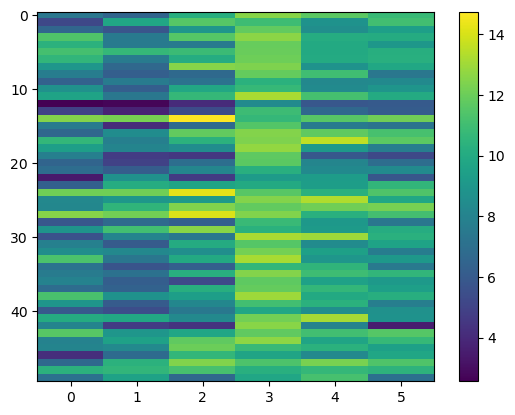

In [195]:
plt.imshow(mrsol["mrsol"].values, aspect="auto")
plt.colorbar()
plt.show()

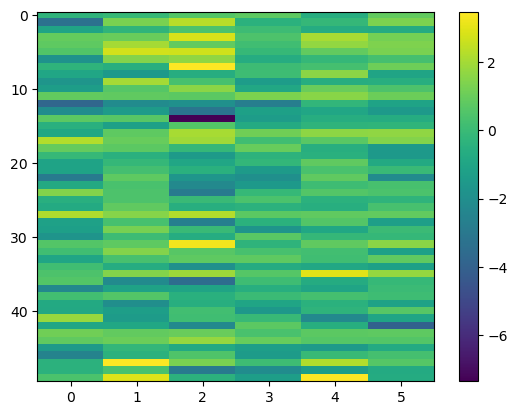

In [ ]:
plt.imshow(res["mrsol"].values, aspect="auto")
plt.colorbar()
plt.show()
